# CAFÉ — it just works

> One line — `cafe.impute(x)` — on **any container, any shape, any dataset**, with a
> **single dependency (numpy)**. No config, no fitting, no surprises.

This notebook is the stress test of that promise: every container type, 1D/2D/3D, a spread
of real-world datasets across domains, missingness-as-signal, and the nasty edge cases — all
through the same call.

**The framing — a "two-of-three".** Prior strong imputers pick at most two of
{**causal / strictly point-in-time**, **CPU-only / zero-config**, **competitive with
bidirectional deep SOTA**}. CAFÉ aims to hold all three at once. Published deep numbers
(SAITS, BRITS, CSDI, …) come from a *different* windowed train/val/test protocol and are
**context only — never a head-to-head leaderboard here**. What this notebook actually
demonstrates is the "just works" surface: that the *same one call* copes with every
container, shape, dataset and edge case a practitioner will throw at it — on a CPU, with
numpy alone, and without ever peeking at the future.


## 0 · Setup — and how few dependencies this really is

In [1]:
import sys, pathlib
_src = pathlib.Path.cwd().parent / "src"
if _src.exists() and str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
import numpy as np
import cafe
print("CAFÉ", cafe.__version__)

CAFÉ 0.1.0


**The core is numpy-only.** Not "numpy plus a few things" — *numpy, full stop*. Here's
the proof: we forcibly block `scipy` (and pandas/polars) from importing, then run the full
model anyway.

In [2]:
import sys
for blocked in ["scipy", "scipy.linalg", "pandas", "polars", "sklearn", "torch"]:
    sys.modules[blocked] = None          # any attempt to import these now fails

import importlib, cafe; importlib.reload(cafe)
x = np.array([1., 2., np.nan, 4., np.nan, 6., 7.])
print("imputed with scipy/pandas/polars/sklearn/torch ALL blocked:", cafe.impute(x))
print("→ a CAFÉ install needs only numpy: it pip-installs in seconds, anywhere.")

for blocked in ["scipy", "scipy.linalg", "pandas", "polars", "sklearn", "torch"]:
    del sys.modules[blocked]             # unblock for the rest of the notebook

imputed with scipy/pandas/polars/sklearn/torch ALL blocked: [1.         2.         2.50000173 4.         4.83333853 6.
 7.        ]
→ a CAFÉ install needs only numpy: it pip-installs in seconds, anywhere.


## 1 · Every container, every shape — one call

numpy / pandas / polars · `Series` / `DataFrame` / `ndarray` · 1D / 2D. Same type comes
back, labels and dtypes preserved, gaps filled.

In [3]:
import pandas as pd, polars as pl
rng = np.random.default_rng(0)

def hole(a, rate=0.2):
    a = a.astype(float).copy(); a[rng.random(a.shape) < rate] = np.nan; return a

X = hole(rng.standard_normal((60, 4)))
cases = {
    "numpy 1D":        X[:, 0],
    "numpy 2D":        X,
    "pandas Series":   pd.Series(X[:, 0], name="s"),
    "pandas DataFrame":pd.DataFrame(X, columns=list("abcd"),
                                    index=pd.date_range("2020", periods=60, freq="h")),
    "polars Series":   pl.Series("s", X[:, 0]),
    "polars DataFrame":pl.DataFrame({c: X[:, i] for i, c in enumerate("abcd")}),
}
for name, obj in cases.items():
    out = cafe.impute(obj)
    arr = np.asarray(out.to_numpy() if hasattr(out, "to_numpy") else out, float)
    print(f"{name:18s} {type(obj).__name__:10s} -> {type(out).__name__:10s} "
          f"shape {arr.shape}  finite={np.isfinite(arr).all()}")

numpy 1D           ndarray    -> ndarray    shape (60,)  finite=True
numpy 2D           ndarray    -> ndarray    shape (60, 4)  finite=True
pandas Series      Series     -> Series     shape (60,)  finite=True
pandas DataFrame   DataFrame  -> DataFrame  shape (60, 4)  finite=True
polars Series      Series     -> Series     shape (60,)  finite=True
polars DataFrame   DataFrame  -> DataFrame  shape (60, 4)  finite=True


Real frames are messy — a date column, a string id, numeric sensors all mixed. CAFÉ
imputes the numeric columns and passes everything else through, order intact. Still one
call.

In [4]:
df = pl.DataFrame({
    "date":   [f"2020-01-{d:02d}" for d in range(1, 41)],
    "region": (["north", "south"] * 20),
    "temp":   hole(rng.standard_normal(40)),
    "load":   hole(rng.standard_normal(40)),
})
out = cafe.impute(df)
print("columns preserved:", out.columns)
print("date/region untouched:", out["date"][0], out["region"][0],
      "| numeric nulls after:", out.select(["temp", "load"]).null_count().sum_horizontal().item())

columns preserved: ['date', 'region', 'temp', 'load']
date/region untouched: 2020-01-01 north | numeric nulls after: 0


## 2 · Panel data — 3D arrays and two-index frames, same one call

Panel data (many entities, each a time series) arrives in two natural shapes, and CAFÉ
takes **either one directly** — no manual stacking, no hand-built id arrays:

- a **3D array** `(entity × time × feature)`, or
- a **long-format frame** with two index columns (a date *and* an id), via `panel=(time_col, entity_col)`.

Both round-trip exactly, leave observed cells untouched, and stay strictly point-in-time.

In [5]:
# A real 3D cube: 8 entities × 50 timesteps × 3 features — hand it over as-is.
cube   = hole(rng.standard_normal((8, 50, 3)), rate=0.25)
filled = cafe.impute(cube)                      # no stacking, no meta — just the array
obs    = ~np.isnan(cube)
print("3D in -> 3D out:", cube.shape, "->", filled.shape,
      "| finite:", np.isfinite(filled).all(),
      "| observed cells untouched:", np.allclose(filled[obs], cube[obs]))

3D in -> 3D out: (8, 50, 3) -> (8, 50, 3) | finite: True | observed cells untouched: True


### …or a long frame with two index columns

A `date` column, a `ticker` column, numeric features — the everyday shape of a financial
or sensor panel. Name the two index columns and CAFÉ pivots, imputes, and hands the
**same frame** back, keys and column order intact.

In [6]:
rows = []
for tkr in ["AAA", "BBB", "CCC"]:
    for d in range(1, 41):
        rows.append({"date": f"2020-01-{d:02d}", "ticker": tkr,
                     "px":  float("nan") if rng.random() < 0.25 else rng.standard_normal(),
                     "vol": float("nan") if rng.random() < 0.25 else rng.standard_normal()})
pf  = pl.DataFrame(rows)
out = cafe.impute(pf, panel=("date", "ticker"))     # two index columns -> panel path
print("rows:", out.height, "| keys preserved:", out["ticker"][:2].to_list(),
      "| numeric nulls after:",
      out.select(["px", "vol"]).null_count().sum_horizontal().item())

rows: 120 | keys preserved: ['AAA', 'AAA'] | numeric nulls after: 0


### Two engines, one knob — and why there's no auto-pick

`engine="joint"` (the default, the validated core) pools the contemporaneous cross-section
— right when entities share structure. `engine="per_entity"` models each series on its own
— better when each series is rich enough that the cross-section adds nothing (long history,
many features). On such a panel per-entity can win by tens of percent.

There is deliberately **no auto-router**: which engine wins is a property of the *data-
generating process* (is the cross-section informative?), not something readable from the
data's shape — so CAFÉ lets you pick, and defaults to the always-safe `joint`.

In [7]:
# Rich panel with a known low-rank truth: long (T=120), wide (F=20). Hide 20%, score both.
E, T, F, R = 12, 120, 20, 5
A = rng.standard_normal((E, R)); W = rng.standard_normal((F, R))
Z = np.cumsum(rng.standard_normal((T, R)) * 0.3, axis=0)
truth = np.einsum("er,tr,fr->etf", A, Z, W) + 0.3 * rng.standard_normal((E, T, F))
mask  = rng.random(truth.shape) < 0.2
cube  = np.where(mask, np.nan, truth)
mae   = lambda P: float(np.abs(truth[mask] - P[mask]).mean())

mj = mae(cafe.impute(cube, engine="joint"))
mp = mae(cafe.impute(cube, engine="per_entity"))
print(f"rich panel   joint MAE {mj:.3f}   |   per_entity MAE {mp:.3f}"
      f"   ->   per_entity {100*(mj-mp)/mj:+.0f}%")
print("default is joint:", np.array_equal(cafe.impute(cube), cafe.impute(cube, engine="joint")))

rich panel   joint MAE 0.672   |   per_entity MAE 0.494   ->   per_entity +26%
default is joint: True


## 3 · A spread of real datasets — diversity is the point

Different domains, sizes and shapes, scored identically (10% held out, standardised MAE).
One loop, one call each — no per-dataset tuning.

In [8]:
import os
DATA = "../data"
specs = [
    ("ETTh1 (energy)",       "ETTh1_clean.npy", "npy"),
    ("Beijing air (wide)",   "beijing_clean.npy", "npy"),
    ("Air quality",          "airq_normal.txt", "txt"),
    ("Chlorine",             "chlorine_normal.txt", "txt"),
    ("Temperature",          "temp_normal.txt", "txt"),
]
rows = []
for name, fn, kind in specs:
    p = os.path.join(DATA, fn)
    if not os.path.exists(p):
        continue
    X = (np.load(p) if kind == "npy" else np.loadtxt(p)).astype(float)
    X = X[:3000]                                   # cap rows so the notebook stays snappy
    Z = (X - np.nanmean(X, 0)) / (np.nanstd(X, 0) + 1e-9)
    m = rng.random(Z.shape) < 0.10
    obs = Z.copy(); obs[m] = np.nan
    import time; t0 = time.perf_counter()
    f = np.asarray(cafe.impute(obs), float); dt = time.perf_counter() - t0
    mae = np.mean(np.abs(f[m] - Z[m]))
    rows.append((name, f"{X.shape[0]}×{X.shape[1]}", mae, dt, np.isfinite(f).all()))

print(f"{'dataset':22s} {'shape':12s} {'MAE':>7s} {'time':>7s}  ok")
print("-" * 56)
for nm, sh, mae, dt, ok in rows:
    print(f"{nm:22s} {sh:12s} {mae:7.3f} {dt:6.2f}s  {'✓' if ok else '✗'}")

dataset                shape            MAE    time  ok
--------------------------------------------------------
ETTh1 (energy)         3000×7         0.258   0.44s  ✓
Beijing air (wide)     3000×132       0.135   1.08s  ✓
Air quality            1000×10        0.314   0.15s  ✓
Chlorine               1000×50        0.104   0.20s  ✓
Temperature            3000×50        0.071   0.63s  ✓


Five datasets, five domains, five shapes — every one filled, finite, in one call, with no
configuration. That's the "just works." These MAEs are CAFÉ scored *against itself* on one
fixed mask, to show consistency across domains — **not** a head-to-head against deep models
(whose published numbers use a different protocol). For the honest, separated causal-vs-
bidirectional comparison see `cafe_benchmark.ipynb`.

## 4 · The nasty edge cases — it doesn't crash, it copes

All-NaN columns, a 1×1 input, constant columns, wild magnitudes, a lone series. A library
that "just works" must return finite, correctly-shaped output on all of them.

In [9]:
def ok(x, meta=None):
    out = np.asarray(cafe.impute(x, meta) if meta else cafe.impute(x), float)
    return f"shape {out.shape}, finite={np.isfinite(out).all()}"

_anan = hole(rng.standard_normal((40, 3))); _anan[:, 0] = np.nan   # column 0 fully missing
print("all-NaN column      :", ok(_anan))
print("1x1                 :", ok(np.array([[3.14]])))
print("constant column     :", ok(np.c_[np.ones(30), hole(rng.standard_normal(30))]))
print("huge & tiny values  :", ok(hole(rng.standard_normal((30,3))) * 1e9))
print("single series (1D)  :", ok(hole(rng.standard_normal(50))))
print("all observed (no NaN):", ok(rng.standard_normal((20, 3))))
print("→ every edge case returns finite, correctly-shaped output.")

all-NaN column      : shape (40, 3), finite=True
1x1                 : shape (1, 1), finite=True
constant column     : shape (30, 2), finite=True
huge & tiny values  : shape (30, 3), finite=True
single series (1D)  : shape (50,), finite=True
all observed (no NaN): shape (20, 3), finite=True
→ every edge case returns finite, correctly-shaped output.


## 5 · Missingness as signal — the fact a value *was* missing survives imputation

Imputation fills holes — but it also **erases** something: *where* the data was missing.
That pattern is often itself informative (a sensor drops out during an event; a field is
skipped for a reason). CAFÉ keeps it. `res.missingness_features()` returns **strictly
forward-only** features (every row `t` uses rows `≤ t` only): a `was_imputed` indicator,
BRITS-style `time_since_obs`, `gap_length`, an expanding `missing_rate`, and a leak-free
`selective_mim` for columns whose missingness is genuinely informative. They are safe to sit
next to the causally-imputed values in a downstream point-in-time model.

Here the demo is deliberately honest: a hidden regime elevates a target `y` **and**
simultaneously knocks sensor `s0` offline. After imputation the hole is filled with a
plausible value — so the imputed matrix alone barely sees the regime. Re-attaching the
causal "was-missing" features recovers it.

In [10]:
from numpy.linalg import lstsq
T, N = 600, 4
base = rng.standard_normal((T, N))
regime = rng.random(T) < 0.25                       # hidden regime
y = 0.3 * base[:, 1] + 1.5 * regime + 0.2 * rng.standard_normal(T)   # downstream target
obs = base.copy()
obs[regime | (rng.random(T) < 0.03), 0] = np.nan    # s0 goes offline during the regime
obs[rng.random((T, N)) < 0.05] = np.nan             # plus light MCAR everywhere
df = pd.DataFrame(obs, columns=[f"s{i}" for i in range(N)])

res = cafe.CAFE().run(df)
filled = res.imputed                                 # holes filled — pattern now invisible
feats = res.missingness_features()                   # same container type, causal features
print("missingness feature columns:", list(feats.columns)[:4], "...",
      f"({feats.shape[1]} total)")

def r2(X, t):                                        # causal R^2 of y on features
    X = np.c_[np.ones(len(X)), X]
    pred = X @ lstsq(X, t, rcond=None)[0]
    return 1 - ((t - pred) ** 2).sum() / ((t - t.mean()) ** 2).sum()

Xf = filled.to_numpy()
was = feats.filter(like="was_imputed").to_numpy()
print(f"R² predicting y from imputed values only        : {r2(Xf, y):.3f}")
print(f"R² adding the causal was-missing features        : {r2(np.c_[Xf, was], y):.3f}")
print("→ the regime lives in the *missingness pattern*; imputation hides it, "
      "these features bring it back — and they never look ahead.")

missingness feature columns: ['s0__was_imputed', 's1__was_imputed', 's2__was_imputed', 's3__was_imputed'] ... (17 total)
R² predicting y from imputed values only        : 0.201
R² adding the causal was-missing features        : 0.738
→ the regime lives in the *missingness pattern*; imputation hides it, these features bring it back — and they never look ahead.


## 6 · And it's still the rich model — one line per view

The same call that "just works" also exposes everything, one line each (see
`cafe_tutorial.ipynb` for the deep dive).

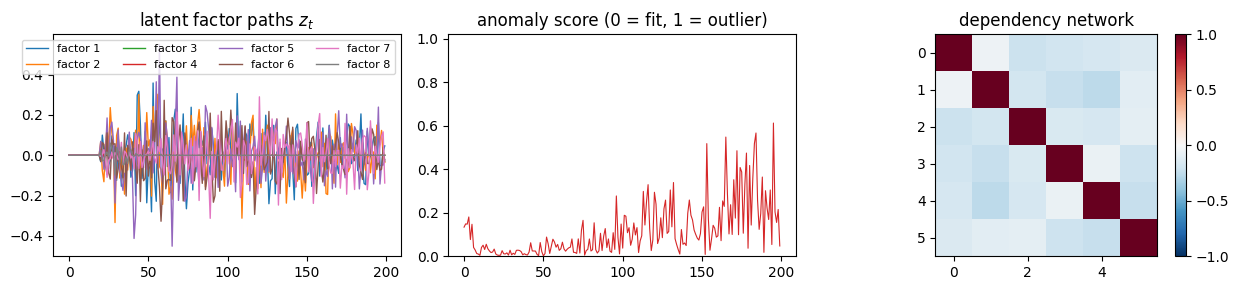

res.plot('uncertainty' | 'factors' | 'anomaly' | 'decomposition' | 'dependency')


In [11]:
import matplotlib.pyplot as plt
res = cafe.CAFE().run(hole(rng.standard_normal((200, 6)), 0.15))
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
res.plot("factors", ax=axes[0])
res.plot("anomaly", ax=axes[1])
res.plot("dependency", ax=axes[2])
plt.tight_layout(); plt.show()
print("res.plot('uncertainty' | 'factors' | 'anomaly' | 'decomposition' | 'dependency')")

## Recap

- **One dependency** (numpy). Installs in seconds; runs where scipy/torch/pandas can't.
- **Any container** (numpy/pandas/polars), **any shape** (1D/2D/3D panel), mixed-type frames.
- **Any dataset** — five domains here, zero configuration, all finite.
- **Survives the edge cases** that break naive imputers.
- **Missingness as signal** — causal `res.missingness_features()` keeps the information that
  imputation would erase, forward-only so it's safe downstream.
- Still the full model: `res.plot(kind)`, `uncertainty`, `factors()`, `anomaly_scores()`,
  `decompose(full=True)`, `dependency_network()`, `forecast` — strictly **no look-ahead**.

The whole point is the **two-of-three**: causal *and* CPU-only *and* in the deep-SOTA band.
Published deep numbers are a different protocol — context, not a head-to-head ranking; the
honest separated comparison lives in `cafe_benchmark.ipynb`.

```bash
pip install cafe-impute      # numpy only
```
